# Strategy 3: Fade the Overreaction (Mean Reversion)

**No hawk/dove labels.** Purely price-action based:
1. Observe the rate move from T-45min to T+30min around each speech (the "reaction")
2. If |reaction| exceeds a threshold, enter the OPPOSITE direction at T+30min
3. Exit at T+3hr or EOD

Tests whether speeches cause short-term overreactions that subsequently revert.

In [1]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.insert(0, r"C:\Users\chris\clee\ARBS")
import datetime, pytz, re, numpy as np, pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt, matplotlib.pylab as pylab, seaborn as sns
plt.style.use("ggplot")
pylab.rcParams.update({"legend.fontsize": "large", "figure.figsize": (14, 8),
    "axes.labelsize": "x-large", "axes.titlesize": "x-large",
    "xtick.labelsize": "large", "ytick.labelsize": "large"})
import QuantLib as ql

NYC_tz = pytz.timezone("America/New_York")
ENTRY_OFFSET = datetime.timedelta(minutes=45)
REACTION_WINDOW = datetime.timedelta(minutes=30)  # observe move until T+30min
EXIT_OFFSET_3H = datetime.timedelta(minutes=180)  # exit at T+3hr
CURVE = "USD-SOFR-1D-Q12STIRT"
TENOR = "IMM_3xIMM_4"
BASE_BPV = 100_000
MDP_SOURCE = "BARCHART_STIRF-RL"
BT_START = "2021-01-01"
BT_END = "2026-06-30"
EARLIEST_SPEECH = datetime.time(7, 0)
LATEST_SPEECH = datetime.time(17, 0)
BLACKOUT_BD = 1

FADE_THRESHOLDS = [0.5, 1.0, 2.0]

print("Config loaded.")

Config loaded.


## 1. Load Data

In [2]:
from RVUtils.forex_factory_calendar import ForexFactoryCalendarFetcher, ForexFactoryTheme
fetcher = ForexFactoryCalendarFetcher()
fed_speak_df = fetcher.fetch_range(BT_START, BT_END,
    themes=[ForexFactoryTheme.FED_SPEAKERS], show_tqdm=True, bulk_chunk_weeks=52)
print(f"ForexFactory events: {len(fed_speak_df)}")

jpm = pd.read_csv(r"C:\Users\chris\clee\project-oasis\private\jpm_research\fed_speak_nlp\fed_hawk_dove_scores.csv")
jpm["date"] = pd.to_datetime(jpm["date"]).dt.date
KNOWN = sorted(jpm["speaker"].unique())
print(f"Known speakers: {len(KNOWN)}")

Fetching missing Forex Factory weeks: 0it [00:00, ?it/s]

Fetching missing Forex Factory weeks: 0it [00:00, ?it/s]

ForexFactory events: 1483
Known speakers: 23


## 2. Engine Setup

In [3]:
from BT.data_handler import TimeGrid
from BT.query_actions import AddQueryAction, UnwindPositionsAction
from BT.query_engine import QueryDrivenBacktest
from BT.query_strategy import QueryStrategy
from BT.triggers import Trigger, FlowSignalTriggerRequirements
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapValue import IRSwapValue

curve_mdp = IRSwapsMDP(source=MDP_SOURCE)

FOMC_DATES = [
    datetime.date(2020,1,29),datetime.date(2020,3,15),datetime.date(2020,4,29),
    datetime.date(2020,6,10),datetime.date(2020,7,29),datetime.date(2020,9,16),
    datetime.date(2020,11,5),datetime.date(2020,12,16),
    datetime.date(2021,1,27),datetime.date(2021,3,17),datetime.date(2021,4,28),
    datetime.date(2021,6,16),datetime.date(2021,7,28),datetime.date(2021,9,22),
    datetime.date(2021,11,3),datetime.date(2021,12,15),
    datetime.date(2022,1,26),datetime.date(2022,3,16),datetime.date(2022,5,4),
    datetime.date(2022,6,15),datetime.date(2022,7,27),datetime.date(2022,9,21),
    datetime.date(2022,11,2),datetime.date(2022,12,14),
    datetime.date(2023,2,1),datetime.date(2023,3,22),datetime.date(2023,5,3),
    datetime.date(2023,6,14),datetime.date(2023,7,26),datetime.date(2023,9,20),
    datetime.date(2023,11,1),datetime.date(2023,12,13),
    datetime.date(2024,1,31),datetime.date(2024,3,20),datetime.date(2024,5,1),
    datetime.date(2024,6,12),datetime.date(2024,7,31),datetime.date(2024,9,18),
    datetime.date(2024,11,7),datetime.date(2024,12,18),
    datetime.date(2025,1,29),datetime.date(2025,3,19),datetime.date(2025,5,7),
    datetime.date(2025,6,18),datetime.date(2025,7,30),datetime.date(2025,9,17),
    datetime.date(2025,10,29),datetime.date(2025,12,10),
    datetime.date(2026,1,28),datetime.date(2026,3,18),datetime.date(2026,4,29),
    datetime.date(2026,6,17),
]
ql_cal = ql.UnitedStates(ql.UnitedStates.GovernmentBond)

def extract_speaker(title):
    cleaned = re.sub(r"\b(Speaks?|Testifies|Testimony)\b", "", title).strip()
    return cleaned.split()[-1] if cleaned.split() else ""

def is_in_blackout(event_date):
    for f in FOMC_DATES:
        s = ql.Date(f.day, f.month, f.year)
        lo = ql_cal.advance(s, ql.Period(-BLACKOUT_BD, ql.Days), ql.Preceding)
        hi = ql_cal.advance(s, ql.Period(BLACKOUT_BD, ql.Days), ql.Following)
        if (datetime.date(lo.year(), lo.month(), lo.dayOfMonth())
                <= event_date <= datetime.date(hi.year(), hi.month(), hi.dayOfMonth())):
            return True
    return False

def cap_exit(exit_ts, entry_ts):
    eq = ql.Date(exit_ts.day, exit_ts.month, exit_ts.year)
    if exit_ts.hour >= 17:
        return exit_ts.replace(hour=16, minute=59, second=0, microsecond=0)
    if not ql_cal.isBusinessDay(eq):
        return entry_ts.replace(hour=16, minute=59, second=0, microsecond=0)
    return exit_ts

def run_bt(events, label):
    if not events:
        return None
    exit_set = set(e["exit_ts"] for e in events)
    ts_all = sorted(set(e["entry_ts"] for e in events) | exit_set)
    exit_trig = Trigger(
        trigger_requirements=FlowSignalTriggerRequirements(
            signal_fn=lambda s, bt: s in exit_set),
        actions=[UnwindPositionsAction(match_all=True, fee=0.0)])
    entry_trigs = []
    for ev in events:
        _ts = ev["entry_ts"]
        _q = IRSwapQuery(curve=CURVE, tenor=TENOR, value=IRSwapValue.NPV,
            structure_kwargs={"bpv": ev["bpv"]}, tags=(ev["tag"],),
            meta={k: ev.get(k) for k in ["speaker","speech_ts_str","reaction_bps"]})
        def _mk(t):
            def fn(s, bt): return s == t and len(bt.portfolio.positions) == 0
            return fn
        entry_trigs.append(Trigger(
            trigger_requirements=FlowSignalTriggerRequirements(signal_fn=_mk(_ts)),
            actions=[AddQueryAction(query=_q)]))
    strat = QueryStrategy(name=label, triggers=[exit_trig] + entry_trigs)
    bt = QueryDrivenBacktest(time_grid=TimeGrid(ts_all), mdp=curve_mdp, strategy=strat,
                             show_progress=True, progress_desc=f"  {label[:30]}")
    bt.run()
    return bt

print("Engine ready.")

Engine ready.


## 3. Pass 1 — Measure Reaction (T-45min to T+30min)

In [4]:
# Build events for ALL eligible speeches: long, entry T-45, exit T+30
# Only keep speakers who appear in JPM scores (have at least some history)
pass1_events = []
for _, row in fed_speak_df.iterrows():
    speaker = extract_speaker(row["Title"])
    if speaker not in KNOWN:
        continue
    ts = row["TimestampNYC"]
    if pd.isna(ts):
        continue
    if ts.tzinfo is None:
        ts = NYC_tz.localize(ts)
    if ts.time() < EARLIEST_SPEECH or ts.time() > LATEST_SPEECH:
        continue
    if is_in_blackout(ts.date()):
        continue
    if "press conference" in row["Title"].lower():
        continue
    entry = ts - ENTRY_OFFSET
    eq = ql.Date(entry.day, entry.month, entry.year)
    if not ql_cal.isBusinessDay(eq):
        continue
    exit_react = ts + REACTION_WINDOW
    exit_react = cap_exit(exit_react, entry)
    pass1_events.append({
        "speaker": speaker, "speech_ts": ts,
        "entry_ts": entry, "exit_ts": exit_react,
        "bpv": -BASE_BPV,
        "tag": f"p1_{len(pass1_events)}",
        "speech_ts_str": str(ts),
        "reaction_bps": 0,
    })

# Dedup — use FULL reaction+fade window for stacking (avoid double-counting)
# The fade trade enters at T+30min and exits at T+3hr, so block the full window
FULL_WINDOW = ENTRY_OFFSET + EXIT_OFFSET_3H  # ~3h45m total
pass1_events.sort(key=lambda e: e["entry_ts"])
filt, last = [], None
for ev in pass1_events:
    if last is not None and ev["entry_ts"] < last:
        continue
    filt.append(ev)
    last = ev["speech_ts"] + EXIT_OFFSET_3H  # block until fade would exit
pass1_events = filt
print(f"Pass 1 events (deduped): {len(pass1_events)}")

bt1 = run_bt(pass1_events, "Pass1: Reaction")
cl1 = pd.DataFrame(bt1.portfolio.closed_positions_log)
cl1["speaker"] = cl1["source_query"].apply(lambda q: q.meta["speaker"])
cl1["speech_ts_str"] = cl1["source_query"].apply(lambda q: q.meta["speech_ts_str"])
cl1["opened_at"] = pd.to_datetime(cl1["opened_at"])
cl1["year"] = cl1["opened_at"].dt.year
cl1["reaction_bps"] = cl1["realized_pnl"] / BASE_BPV
cl1["abs_reaction"] = cl1["reaction_bps"].abs()

print(f"Pass 1 closed: {len(cl1)}")
print(f"Mean |reaction|: {cl1['abs_reaction'].mean():.2f} bps")
print(f"Median |reaction|: {cl1['abs_reaction'].median():.2f} bps")

Pass 1 events (deduped): 733


  Pass1: Reaction:   0%|          | 0/1466 [00:00<?, ?step/s]

  Pass1: Reaction:   0%|          | 1/1466 [00:00<11:36,  2.10step/s]

  Pass1: Reaction:   0%|          | 5/1466 [00:00<02:27,  9.87step/s]

  Pass1: Reaction:   1%|          | 9/1466 [00:00<01:36, 15.14step/s]

...

  Pass1: Reaction:  99%|█████████▉| 1457/1466 [01:04<00:00, 30.11step/s]

  Pass1: Reaction: 100%|█████████▉| 1461/1466 [01:04<00:00, 29.18step/s]

  Pass1: Reaction: 100%|█████████▉| 1465/1466 [01:05<00:00, 29.58step/s]

  Pass1: Reaction: 100%|██████████| 1466/1466 [01:05<00:00, 22.54step/s]

Pass 1 closed: 732
Mean |reaction|: 1.43 bps
Median |reaction|: 0.68 bps


## 4. Reaction Distribution

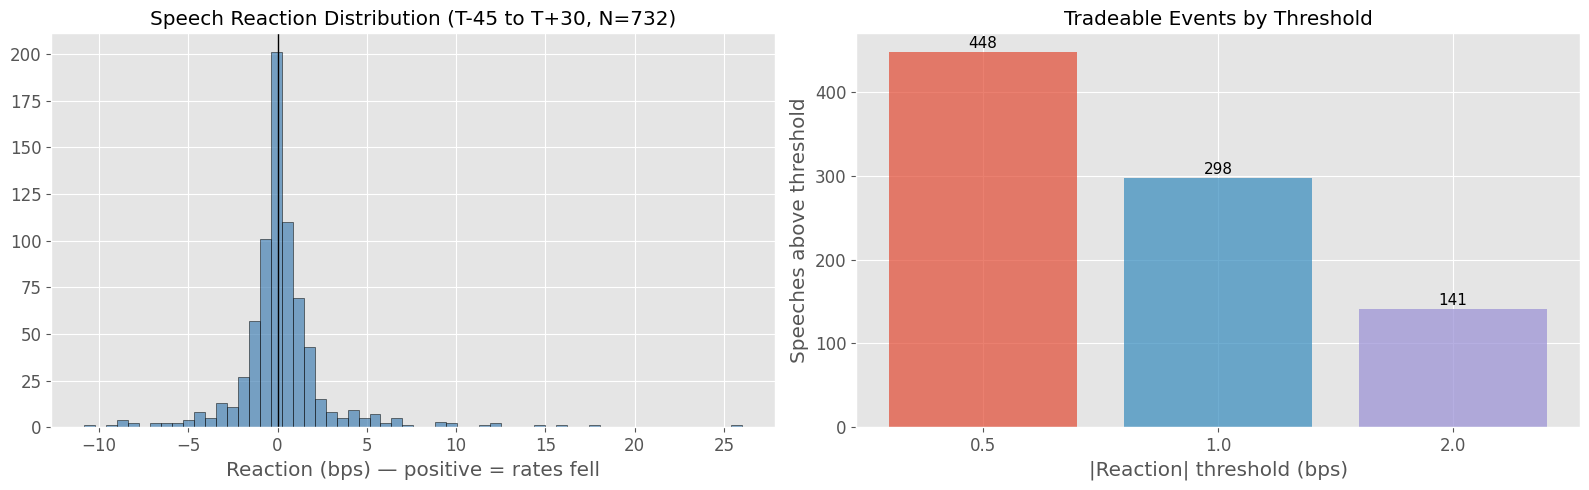

Reaction magnitude by year:
  Year     N    Mean     Med  N>=0.5   N>=1   N>=2
  2021   106    0.25    0.00      15      6      2
  2022    95    2.08    1.40      69     56     36
  2023   119    1.99    1.30      91     67     36
  2024   158    1.78    0.89     116     75     29
  2025   181    1.28    0.64     108     70     31
  2026    73    1.04    0.79      49     24      7


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.hist(cl1["reaction_bps"], bins=60, alpha=0.7, color="steelblue", edgecolor="black")
ax.axvline(0, color="k", lw=1)
ax.set_xlabel("Reaction (bps) — positive = rates fell")
ax.set_title(f"Speech Reaction Distribution (T-45 to T+30, N={len(cl1)})")

ax2 = axes[1]
for thresh in FADE_THRESHOLDS:
    n_above = (cl1["abs_reaction"] >= thresh).sum()
    ax2.bar(str(thresh), n_above, alpha=0.7)
    ax2.text(str(thresh), n_above + 5, str(n_above), ha="center", fontsize=11)
ax2.set_xlabel("|Reaction| threshold (bps)")
ax2.set_ylabel("Speeches above threshold")
ax2.set_title("Tradeable Events by Threshold")
plt.tight_layout(); plt.show()

# Year breakdown of |reaction|
print("Reaction magnitude by year:")
print(f"{'Year':>6s} {'N':>5s} {'Mean':>7s} {'Med':>7s} {'N>=0.5':>7s} {'N>=1':>6s} {'N>=2':>6s}")
for yr, grp in cl1.groupby("year"):
    print(f"{yr:6d} {len(grp):5d} {grp['abs_reaction'].mean():7.2f} {grp['abs_reaction'].median():7.2f} "
          f"{(grp['abs_reaction']>=0.5).sum():7d} {(grp['abs_reaction']>=1.0).sum():6d} {(grp['abs_reaction']>=2.0).sum():6d}")

## 5. Pass 2 — Fade Trades

In [6]:
def build_fade_events(cl1_df, threshold, exit_mode="t3h"):
    events = []
    for _, r in cl1_df.iterrows():
        if r["abs_reaction"] < threshold:
            continue
        speech_ts = r["opened_at"] + ENTRY_OFFSET  # reconstruct speech_ts from entry

        fade_dir = -1 if r["reaction_bps"] > 0 else 1
        fade_bpv = -fade_dir * BASE_BPV

        entry_ts = speech_ts + REACTION_WINDOW
        # strip tz for QuantLib compatibility, re-add after
        entry_naive = entry_ts.replace(tzinfo=None)
        entry_ql = ql.Date(entry_naive.day, entry_naive.month, entry_naive.year)
        if not ql_cal.isBusinessDay(entry_ql):
            continue

        if exit_mode == "t3h":
            exit_ts = speech_ts + EXIT_OFFSET_3H
        else:
            exit_ts = entry_ts.replace(hour=16, minute=59, second=0, microsecond=0)

        exit_ts = cap_exit(exit_ts, entry_ts)
        if exit_ts <= entry_ts:
            continue

        events.append({
            "speaker": r["speaker"],
            "entry_ts": entry_ts, "exit_ts": exit_ts,
            "reaction_bps": float(r["reaction_bps"]),
            "bpv": fade_bpv,
            "tag": f"f_{len(events)}",
            "speech_ts_str": str(speech_ts),
        })

    events.sort(key=lambda e: e["entry_ts"])
    filt, last = [], None
    for ev in events:
        if last is not None and ev["entry_ts"] < last:
            continue
        filt.append(ev)
        last = ev["exit_ts"]
    return filt

results = {}
for thresh in FADE_THRESHOLDS:
    for exit_mode in ["t3h", "eod"]:
        label = f"Fade |r|>={thresh}bp, exit={exit_mode}"
        evts = build_fade_events(cl1, thresh, exit_mode)
        if len(evts) < 5:
            print(f"{label}: only {len(evts)} events, skipping")
            continue
        print(f"\n{label}: {len(evts)} events")
        bt2 = run_bt(evts, label)
        if bt2 is None:
            continue
        cl2 = pd.DataFrame(bt2.portfolio.closed_positions_log)
        if cl2.empty:
            print("  No closed trades")
            continue
        cl2["speaker"] = cl2["source_query"].apply(lambda q: q.meta["speaker"])
        cl2["reaction_bps"] = cl2["source_query"].apply(lambda q: q.meta["reaction_bps"])
        cl2["opened_at"] = pd.to_datetime(cl2["opened_at"], utc=True).dt.tz_convert("America/New_York")
        cl2["year"] = cl2["opened_at"].dt.year
        cl2["pnl_bps"] = cl2["realized_pnl"] / BASE_BPV
        cl2["profitable"] = cl2["pnl_bps"] > 0
        cl2["cum_bps"] = cl2["pnl_bps"].cumsum()
        results[(thresh, exit_mode)] = cl2
        print(f"  Closed: {len(cl2)}, Cum: {cl2['pnl_bps'].sum():+.1f} bps")

print(f"\nCompleted {len(results)} strategy variants.")


Fade |r|>=0.5bp, exit=t3h: 436 events


  Fade |r|>=0.5bp, exit=t3h:   0%|          | 0/872 [00:00<?, ?step/s]

  Fade |r|>=0.5bp, exit=t3h:   0%|          | 3/872 [00:00<00:36, 23.80step/s]

  Fade |r|>=0.5bp, exit=t3h:   1%|          | 7/872 [00:00<00:32, 26.60step/s]

  Fade |r|>=0.5bp, exit=t3h:   1%|▏         | 11/872 [00:00<00:30, 28.33step/s]

...

  Fade |r|>=2.0bp, exit=eod:  97%|█████████▋| 258/266 [00:10<00:00, 20.51step/s]

  Fade |r|>=2.0bp, exit=eod:  98%|█████████▊| 261/266 [00:10<00:00, 21.54step/s]

  Fade |r|>=2.0bp, exit=eod: 100%|█████████▉| 265/266 [00:10<00:00, 23.38step/s]

  Fade |r|>=2.0bp, exit=eod: 100%|██████████| 266/266 [00:10<00:00, 24.89step/s]

  Closed: 133, Cum: +114.3 bps

Completed 6 strategy variants.


## 6. Summary Comparison

In [7]:
def _sharpe(cl):
    n = len(cl)
    yrs = max((cl["opened_at"].max() - cl["opened_at"].min()).days / 365.25, 0.5)
    tpy = n / yrs; std = cl["pnl_bps"].std(); avg = cl["pnl_bps"].mean()
    return (avg / std * np.sqrt(tpy)) if std > 0 else 0

rows = []
for (thresh, exit_mode), cl in results.items():
    n = len(cl)
    rows.append({
        "Threshold": f"|r|>={thresh}",
        "Exit": exit_mode,
        "Trades": n,
        "Cum bps": cl["pnl_bps"].sum(),
        "Avg bps": cl["pnl_bps"].mean(),
        "Med bps": cl["pnl_bps"].median(),
        "Std bps": cl["pnl_bps"].std(),
        "Hit Rate": cl["profitable"].mean(),
        "Sharpe": _sharpe(cl),
        "Max DD": (cl["cum_bps"] - cl["cum_bps"].cummax()).min(),
    })

summary = pd.DataFrame(rows)
display(summary.style.format({
    "Cum bps": "{:+.1f}", "Avg bps": "{:+.3f}", "Med bps": "{:+.3f}",
    "Std bps": "{:.2f}", "Hit Rate": "{:.1%}", "Sharpe": "{:.2f}",
    "Max DD": "{:.1f}",
}).background_gradient(subset=["Sharpe"], cmap="RdYlGn"))

,Threshold,Exit,Trades,Cum bps,Avg bps,Med bps,Std bps,Hit Rate,Sharpe,Max DD
0,|r|>=0.5,t3h,436,+62.9,+0.144,+0.007,3.09,51.4%,0.42,-51.9
1,|r|>=0.5,eod,387,+133.6,+0.345,+0.145,4.04,53.2%,0.73,-77.6
2,|r|>=1.0,t3h,290,+65.3,+0.225,-0.013,3.54,49.0%,0.50,-49.8
3,|r|>=1.0,eod,271,+114.1,+0.421,+0.254,4.57,52.4%,0.70,-75.8
4,|r|>=2.0,t3h,138,+84.0,+0.609,+0.002,4.58,50.0%,0.72,-37.1
5,|r|>=2.0,eod,133,+114.3,+0.860,+0.663,5.82,56.4%,0.78,-66.9


## 7. Equity Curves

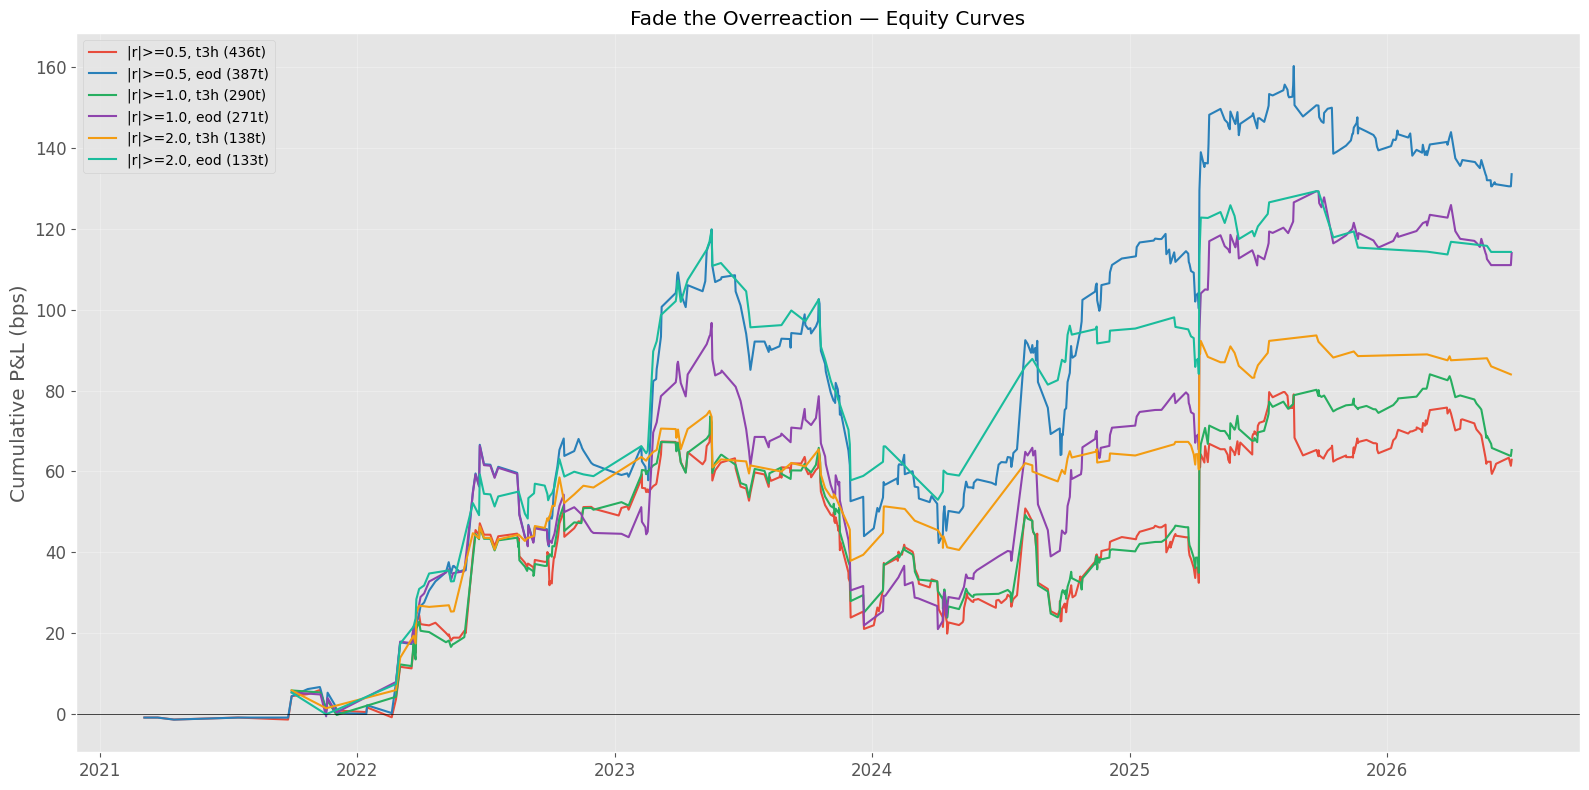

In [8]:
COLORS_FADE = ["#e74c3c", "#2980b9", "#27ae60", "#8e44ad", "#f39c12", "#1abc9c"]

fig, ax = plt.subplots(figsize=(16, 8))
for idx, ((thresh, exit_mode), cl) in enumerate(results.items()):
    label = f"|r|>={thresh}, {exit_mode} ({len(cl)}t)"
    ax.plot(cl["opened_at"].values, cl["cum_bps"].values,
            lw=1.5, color=COLORS_FADE[idx % len(COLORS_FADE)], label=label)
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("Cumulative P&L (bps)")
ax.set_title("Fade the Overreaction — Equity Curves")
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 8. Calendar-Year Breakdown

Best variant: |r|>=2.0, exit=eod (Sharpe=0.78)


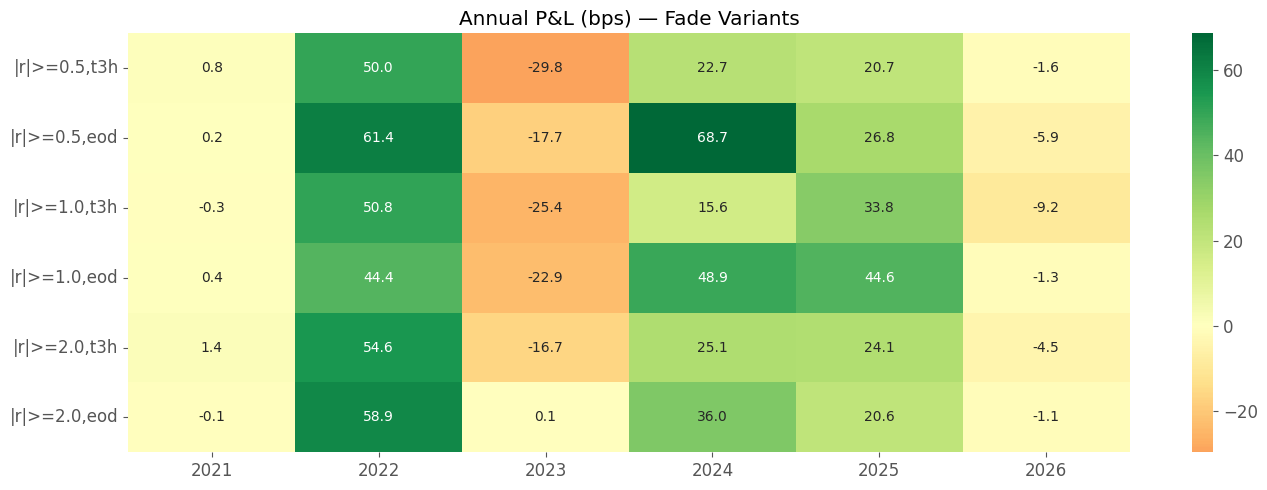

In [9]:
# Pick best variant for detailed analysis
best_key = max(results.keys(), key=lambda k: _sharpe(results[k]))
print(f"Best variant: |r|>={best_key[0]}, exit={best_key[1]} (Sharpe={_sharpe(results[best_key]):.2f})")

# Year heatmap for all variants
all_years = sorted(set(y for cl in results.values() for y in cl["year"].unique()))
yr_data = {}
for (thresh, exit_mode), cl in results.items():
    label = f"|r|>={thresh},{exit_mode}"
    yr_data[label] = {}
    for yr, grp in cl.groupby("year"):
        yr_data[label][yr] = grp["pnl_bps"].sum()

yr_df = pd.DataFrame(yr_data, index=all_years).T.fillna(0)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(yr_df.astype(float), annot=True, fmt=".1f", cmap="RdYlGn", center=0, ax=ax)
ax.set_title("Annual P&L (bps) — Fade Variants")
plt.tight_layout(); plt.show()

## 9. Best Variant — Detailed Analytics

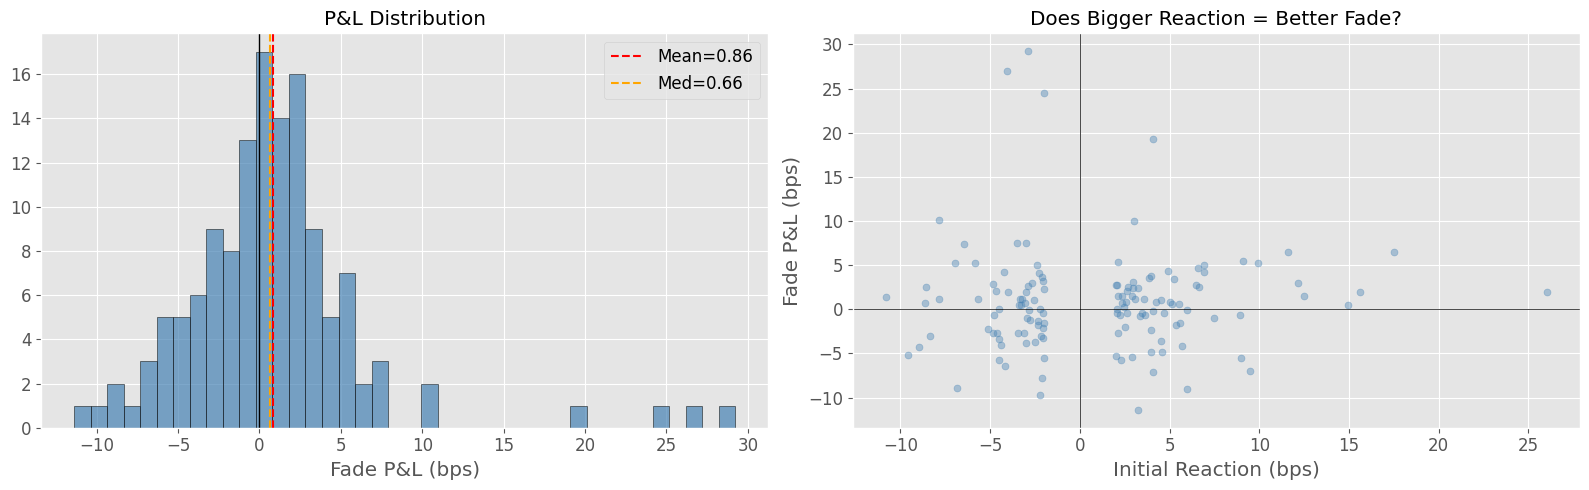

,trades,total_bps,avg_bps,hit_rate,std_bps,sharpe
year,,,,,,
2021,2,-0.1,-0.052,50.0%,7.57,-0.01
2022,36,+58.9,+1.637,63.9%,4.70,2.09
2023,34,+0.1,+0.002,52.9%,6.48,0.00
2024,25,+36.0,+1.438,60.0%,6.29,1.14
2025,29,+20.6,+0.709,51.7%,6.61,0.58
2026,7,-1.1,-0.153,42.9%,1.28,-0.31


In [10]:
cl = results[best_key]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.hist(cl["pnl_bps"], bins=40, alpha=0.7, color="steelblue", edgecolor="black")
ax.axvline(0, color="k", lw=1)
avg = cl["pnl_bps"].mean(); med = cl["pnl_bps"].median()
ax.axvline(avg, color="red", ls="--", label=f"Mean={avg:.2f}")
ax.axvline(med, color="orange", ls="--", label=f"Med={med:.2f}")
ax.set_xlabel("Fade P&L (bps)"); ax.set_title("P&L Distribution"); ax.legend()

ax2 = axes[1]
ax2.scatter(cl["reaction_bps"].astype(float), cl["pnl_bps"], alpha=0.4, s=25, color="steelblue")
ax2.axhline(0, color="k", lw=0.5); ax2.axvline(0, color="k", lw=0.5)
ax2.set_xlabel("Initial Reaction (bps)"); ax2.set_ylabel("Fade P&L (bps)")
ax2.set_title("Does Bigger Reaction = Better Fade?")
plt.tight_layout(); plt.show()

yr_stats = cl.groupby("year").agg(
    trades=("pnl_bps", "count"), total_bps=("pnl_bps", "sum"),
    avg_bps=("pnl_bps", "mean"), hit_rate=("profitable", "mean"),
    std_bps=("pnl_bps", "std"))
yr_stats["sharpe"] = (yr_stats["avg_bps"] / yr_stats["std_bps"]) * np.sqrt(yr_stats["trades"])
display(yr_stats.style.format({
    "total_bps": "{:+.1f}", "avg_bps": "{:+.3f}", "hit_rate": "{:.1%}",
    "std_bps": "{:.2f}", "sharpe": "{:.2f}"}))

## 10. Reversion Rate Analysis

In [11]:
# For each speech with |reaction| >= best threshold, did the fade work?
thresh_best = best_key[0]
eligible = cl1[cl1["abs_reaction"] >= thresh_best].copy()
eligible["year"] = eligible["opened_at"].dt.year

print(f"Speeches with |reaction| >= {thresh_best}bp:")
print(f"{'Year':>6s} {'N':>5s} {'MeanReact':>10s} {'Rates Rose':>11s} {'Rates Fell':>11s}")
for yr, grp in eligible.groupby("year"):
    n_rose = (grp["reaction_bps"] < 0).sum()
    n_fell = (grp["reaction_bps"] > 0).sum()
    print(f"{yr:6d} {len(grp):5d} {grp['reaction_bps'].mean():+10.2f} {n_rose:11d} {n_fell:11d}")

Speeches with |reaction| >= 2.0bp:
  Year     N  MeanReact  Rates Rose  Rates Fell
  2021     2      -1.46           1           1
  2022    36      +0.78          14          22
  2023    36      +0.26          21          15
  2024    29      +2.30          12          17
  2025    31      +0.76          15          16
  2026     7      -1.10           5           2


## 11. Speaker Attribution

,trades,total_bps,avg_bps,hit_rate
speaker,,,,
Powell,22,+30.8,+1.400,59.1%
Barkin,6,+25.7,+4.290,33.3%
Brainard,4,+25.6,+6.412,100.0%
Musalem,5,+15.4,+3.090,100.0%
Mester,4,+13.9,+3.482,75.0%
Jefferson,4,+10.3,+2.567,50.0%
Kashkari,6,+9.2,+1.536,66.7%
Bowman,9,+8.5,+0.942,66.7%
Goolsbee,8,+6.2,+0.774,25.0%


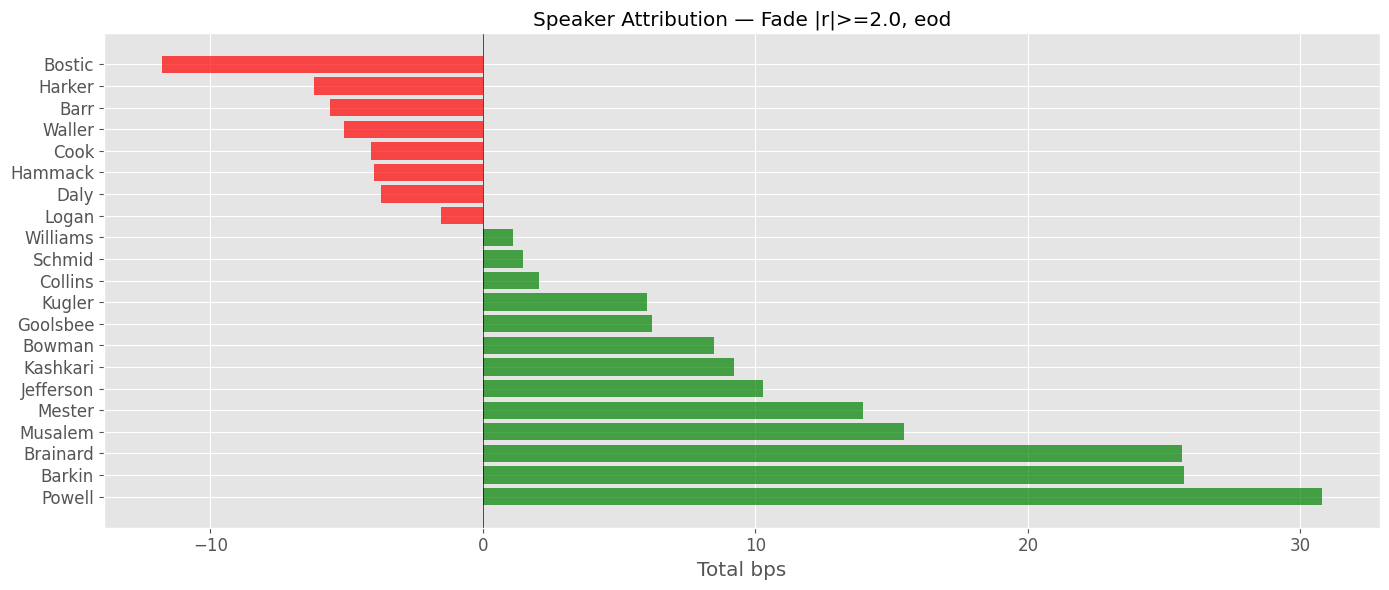

In [12]:
cl = results[best_key]
sp = cl.groupby("speaker").agg(
    trades=("pnl_bps", "count"), total_bps=("pnl_bps", "sum"),
    avg_bps=("pnl_bps", "mean"), hit_rate=("profitable", "mean")
).sort_values("total_bps", ascending=False)

display(sp.style.format({
    "total_bps": "{:+.1f}", "avg_bps": "{:+.3f}", "hit_rate": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(14, 6))
colors = ["green" if x > 0 else "red" for x in sp["total_bps"]]
ax.barh(sp.index, sp["total_bps"], color=colors, alpha=0.7)
ax.axvline(0, color="k", lw=0.5); ax.set_xlabel("Total bps")
ax.set_title(f"Speaker Attribution — Fade |r|>={best_key[0]}, {best_key[1]}")
plt.tight_layout(); plt.show()